# Vector Databases: From Text to Images

Search by **meaning**, not keywords. Works for text AND images!

**What you'll build:**
-  Semantic text search (find similar documents)
-  Image search with natural language ("a cute cat")
-  Reverse image search (find similar images)
-  Using FAISS, Qdrant, and NumPy

Let's go!

---
# Part 1: Text Search 

## Setup

In [3]:
from sentence_transformers import SentenceTransformer
import numpy as np
import faiss

print("Imports ready!")

Imports ready!


## Sample Documents

In [4]:
docs = [
    "Delhi air pollution levels spike due to brick kilns",
    "AQI improving after monsoon rains in NCR region", 
    "New solar panel installations break records in India",
    "Electric vehicle sales surge 40% this quarter",
    "Forest fires in Amazon release massive carbon emissions",
    "Arctic ice melting faster than predicted by models",
    "Renewable energy now cheaper than coal in most markets",
    "Delhi government announces odd-even traffic scheme"
]

print(f"{len(docs)} documents loaded")

8 documents loaded


## Create Text Embeddings

In [5]:
# Load model
text_model = SentenceTransformer('all-MiniLM-L6-v2')

# Create embeddings
text_embeddings = text_model.encode(docs)
text_embeddings = np.array(text_embeddings).astype('float32')

print(f"   Text embeddings: {text_embeddings.shape}")
print(f"   Each doc → {text_embeddings.shape[1]}-dim vector")

   Text embeddings: (8, 384)
   Each doc → 384-dim vector


## Build Vector Database (3 Ways)

In [6]:
# 1. FAISS (fastest)
text_index = faiss.IndexFlatL2(text_embeddings.shape[1])
text_index.add(text_embeddings)
print(f"  FAISS index: {text_index.ntotal} vectors")

# 2. Qdrant (production-ready)
try:
    from qdrant_client import QdrantClient
    from qdrant_client.models import Distance, VectorParams, PointStruct
    
    qdrant = QdrantClient(":memory:")
    qdrant.create_collection(
        collection_name="docs",
        vectors_config=VectorParams(size=text_embeddings.shape[1], distance=Distance.COSINE)
    )
    points = [
        PointStruct(id=i, vector=emb.tolist(), payload={"text": doc})
        for i, (emb, doc) in enumerate(zip(text_embeddings, docs))
    ]
    qdrant.upsert(collection_name="docs", points=points)
    print(f"  Qdrant: {len(docs)} vectors")
    qdrant_available = True
except ImportError:
    print("   Qdrant not installed (optional)")
    qdrant_available = False

# 3. NumPy (DIY)
def numpy_search(query_vec, embeddings_db, k=3):
    query_norm = query_vec / np.linalg.norm(query_vec)
    db_norm = embeddings_db / np.linalg.norm(embeddings_db, axis=1, keepdims=True)
    similarities = db_norm @ query_norm
    top_k = np.argsort(similarities)[::-1][:k]
    return top_k, similarities[top_k]

print("  NumPy search ready")

  FAISS index: 8 vectors
  Qdrant: 8 vectors
  NumPy search ready


## Search Text

Unified search function - choose your implementation!

In [ ]:
def search_text(query, k=3, method="faiss"):
    """Search documents using different vector DB implementations."""
    query_vec = text_model.encode([query])[0].astype('float32')
    print(f"\nSearching: '{query}' ({method})\n" + "="*60)
    
    if method == "faiss":
        distances, indices = text_index.search(query_vec.reshape(1, -1), k)
        for i, (idx, dist) in enumerate(zip(indices[0], distances[0]), 1):
            print(f"{i}. {docs[idx]}")
            print(f"   Distance: {dist:.3f}\n")
    
    elif method == "qdrant" and qdrant_available:
        results = qdrant.query_points(
            collection_name="docs",
            query=query_vec.tolist(),
            limit=k
        )
        for i, point in enumerate(results.points, 1):
            print(f"{i}. {point.payload['text']}")
            print(f"   Score: {point.score:.3f}\n")
    
    elif method == "numpy":
        indices, similarities = numpy_search(query_vec, text_embeddings, k)
        for i, (idx, sim) in enumerate(zip(indices, similarities), 1):
            print(f"{i}. {docs[idx]}")
            print(f"   Similarity: {sim:.3f}\n")
    
    else:
        print(f"Method '{method}' not available")

In [8]:
# FAISS
search_text("air quality in Delhi", k=3, method="faiss")


🔍 'air quality in Delhi' (faiss)
1. Delhi air pollution levels spike due to brick kilns
   Distance: 0.706

2. AQI improving after monsoon rains in NCR region
   Distance: 1.117

3. Delhi government announces odd-even traffic scheme
   Distance: 1.321



In [9]:
search_text("air quality in Delhi", k=3, method="numpy")


🔍 'air quality in Delhi' (numpy)
1. Delhi air pollution levels spike due to brick kilns
   Similarity: 0.647

2. AQI improving after monsoon rains in NCR region
   Similarity: 0.441

3. Delhi government announces odd-even traffic scheme
   Similarity: 0.339



In [10]:
# Qdrant (if available)
if qdrant_available:
    search_text("climate change impacts", k=3, method="qdrant")


🔍 'climate change impacts' (qdrant)
1. Forest fires in Amazon release massive carbon emissions
   Score: 0.370

2. Arctic ice melting faster than predicted by models
   Score: 0.339

3. AQI improving after monsoon rains in NCR region
   Score: 0.269



In [11]:
# NumPy
search_text("renewable energy and sustainability", k=3, method="numpy")


🔍 'renewable energy and sustainability' (numpy)
1. Renewable energy now cheaper than coal in most markets
   Similarity: 0.608

2. New solar panel installations break records in India
   Similarity: 0.249

3. Electric vehicle sales surge 40% this quarter
   Similarity: 0.194



---
# Part 2: Image Search

Now the fun part - search images with text OR other images!

## Setup CLIP Model

In [13]:
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
from transformers import CLIPProcessor, CLIPModel

# Load CLIP (works for both images AND text!)
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

print("  CLIP model loaded!")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

  CLIP model loaded!


## Load Sample Images

  8 images loaded



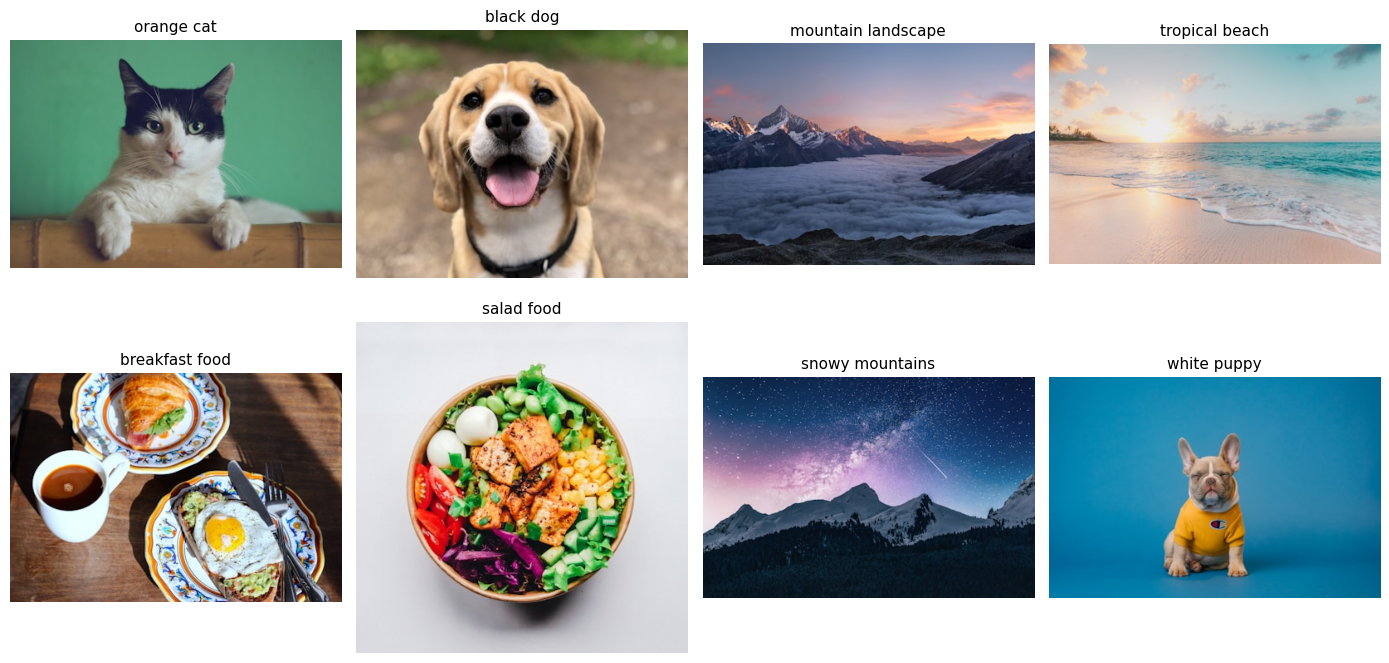

In [14]:
# Small image dataset from Unsplash
image_data = [
    {"url": "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=400", "desc": "orange cat"},
    {"url": "https://images.unsplash.com/photo-1543466835-00a7907e9de1?w=400", "desc": "black dog"},
    {"url": "https://images.unsplash.com/photo-1506905925346-21bda4d32df4?w=400", "desc": "mountain landscape"},
    {"url": "https://images.unsplash.com/photo-1507525428034-b723cf961d3e?w=400", "desc": "tropical beach"},
    {"url": "https://images.unsplash.com/photo-1551963831-b3b1ca40c98e?w=400", "desc": "breakfast food"},
    {"url": "https://images.unsplash.com/photo-1546069901-ba9599a7e63c?w=400", "desc": "salad food"},
    {"url": "https://images.unsplash.com/photo-1519681393784-d120267933ba?w=400", "desc": "snowy mountains"},
    {"url": "https://images.unsplash.com/photo-1583511655857-d19b40a7a54e?w=400", "desc": "white puppy"},
]

# Download
images = []
image_descriptions = []

for item in image_data:
    response = requests.get(item["url"])
    img = Image.open(BytesIO(response.content)).convert('RGB')
    images.append(img)
    image_descriptions.append(item["desc"])

print(f"  {len(images)} images loaded\n")

# Display
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for idx, (img, desc) in enumerate(zip(images, image_descriptions)):
    ax = axes[idx // 4, idx % 4]
    ax.imshow(img)
    ax.set_title(desc, fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Create Image Embeddings

In [15]:
def get_image_embedding(image):
    inputs = clip_processor(images=image, return_tensors="pt")
    image_features = clip_model.get_image_features(**inputs)
    embedding = image_features.detach().numpy()[0]
    return embedding / np.linalg.norm(embedding)  # normalize

# Generate embeddings
image_embeddings = np.array([get_image_embedding(img) for img in images]).astype('float32')

print(f"   Image embeddings: {image_embeddings.shape}")
print(f"   Each image → {image_embeddings.shape[1]}-dim vector")

   Image embeddings: (8, 512)
   Each image → 512-dim vector


## Build Image Vector Database

In [16]:
# FAISS index for images (using inner product for normalized vectors)
image_index = faiss.IndexFlatIP(image_embeddings.shape[1])
image_index.add(image_embeddings)

print(f"  Image index: {image_index.ntotal} images")

  Image index: 8 images


## Search Images with Text

CLIP's magic: same embedding space for text AND images!

In [18]:
def search_images_by_text(query, k=3):
    # Convert text to embedding
    inputs = clip_processor(text=query, return_tensors="pt")
    text_features = clip_model.get_text_features(**inputs)
    query_vec = text_features.detach().numpy()[0]
    query_vec = query_vec / np.linalg.norm(query_vec)
    
    # Search
    similarities, indices = image_index.search(query_vec.reshape(1, -1).astype('float32'), k)
    
    # Display
    print(f"\n  '{query}'\n")
    fig, axes = plt.subplots(1, k, figsize=(12, 4))
    for i, (idx, sim) in enumerate(zip(indices[0], similarities[0])):
        ax = axes[i] if k > 1 else axes
        ax.imshow(images[idx])
        ax.set_title(f"{image_descriptions[idx]}\nScore: {sim:.3f}", fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()



  'a cute pet animal'



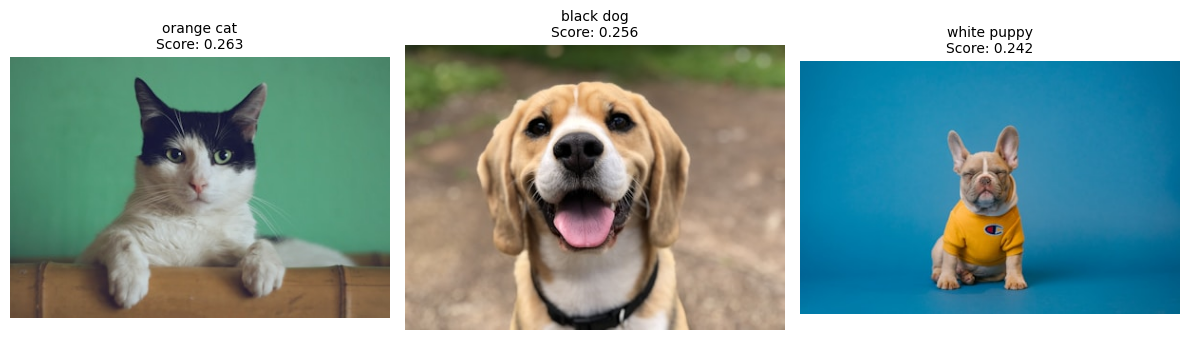

In [19]:
search_images_by_text("a cute pet animal", k=3)


  'beautiful outdoor scenery'



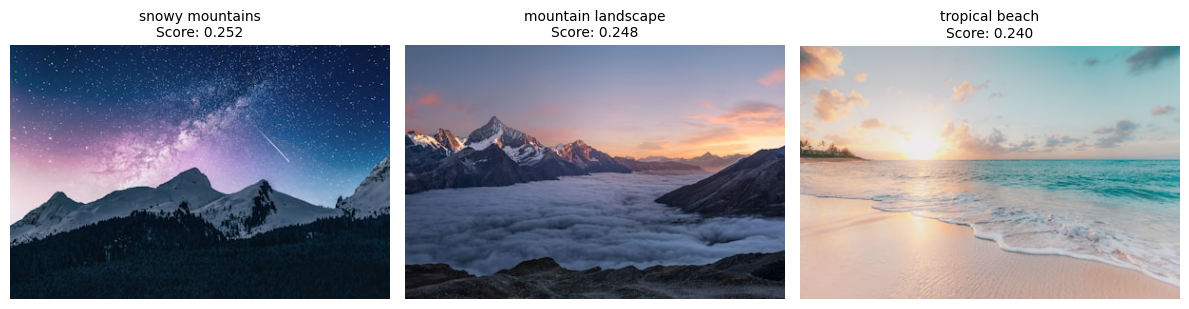

In [20]:
search_images_by_text("beautiful outdoor scenery", k=3)


  'delicious meal'



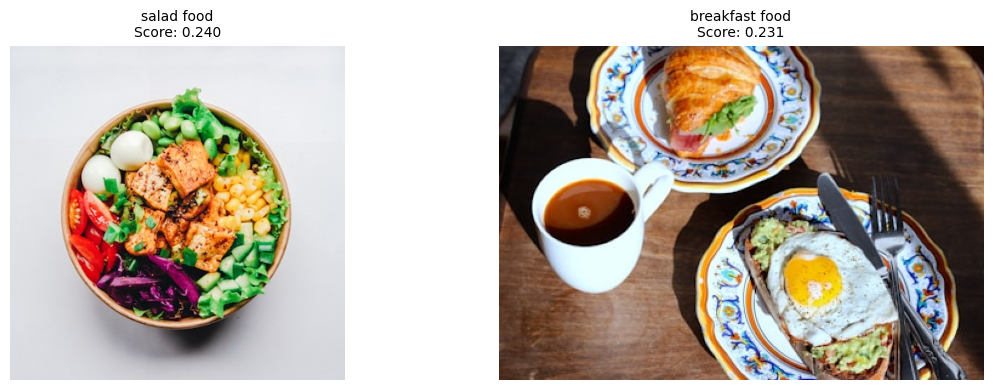

In [22]:
search_images_by_text("delicious meal", k=2)

## Reverse Image Search

Find similar images using another image as query!


  Query: orange cat



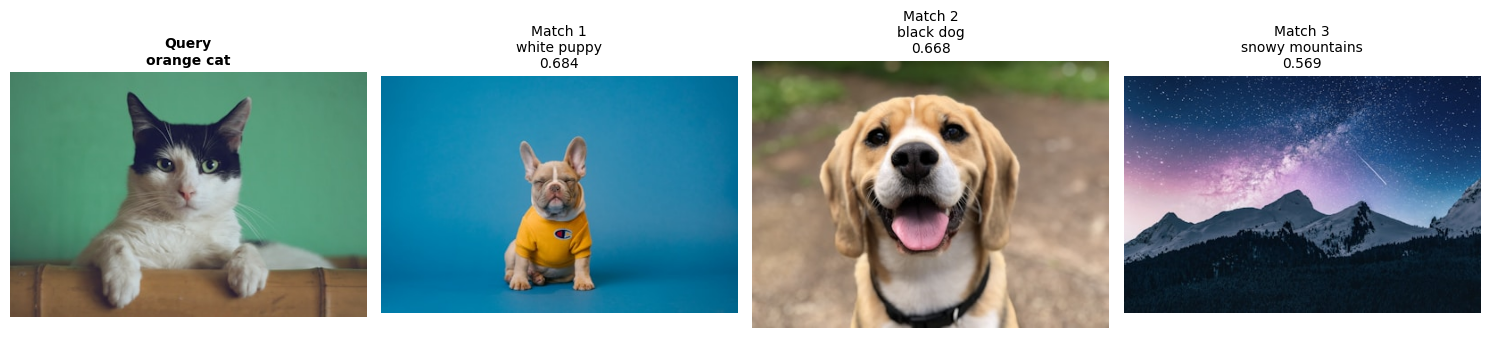

In [24]:
def search_images_by_image(query_idx, k=3):
    query_vec = image_embeddings[query_idx]
    similarities, indices = image_index.search(query_vec.reshape(1, -1), k+1)
    
    print(f"\n  Query: {image_descriptions[query_idx]}\n")
    
    fig, axes = plt.subplots(1, k+1, figsize=(15, 4))
    
    # Query image
    axes[0].imshow(images[query_idx])
    axes[0].set_title(f"Query\n{image_descriptions[query_idx]}", fontsize=10, fontweight='bold')
    axes[0].axis('off')
    
    # Similar images (skip first = query itself)
    for i, (idx, sim) in enumerate(zip(indices[0][1:], similarities[0][1:]), 1):
        axes[i].imshow(images[idx])
        axes[i].set_title(f"Match {i}\n{image_descriptions[idx]}\n{sim:.3f}", fontsize=10)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Find images similar to cat
search_images_by_image(0, k=3)


  Query: mountain landscape



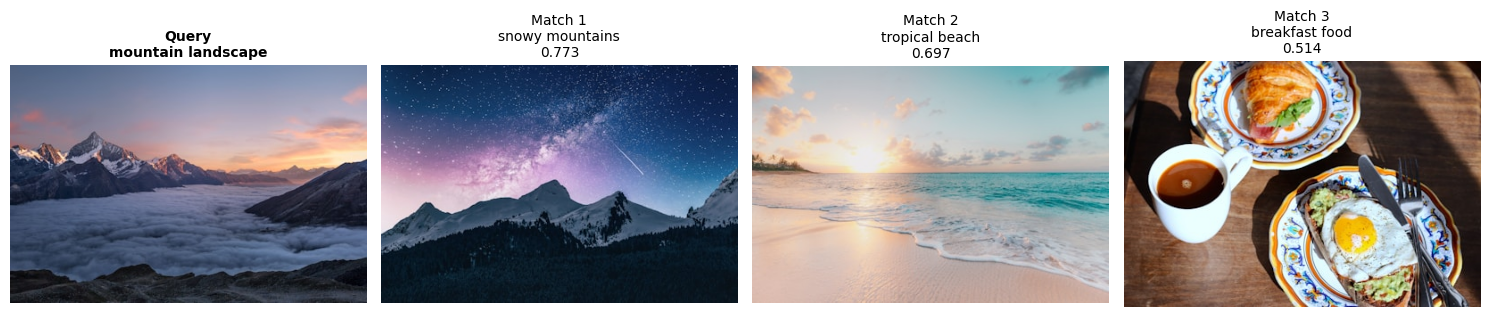

In [25]:
# Find images similar to mountains
search_images_by_image(2, k=3)

## Bonus: Search with Any URL

In [ ]:
def search_by_url(image_url, k=3):
    # Download
    response = requests.get(image_url)
    query_image = Image.open(BytesIO(response.content)).convert('RGB')
    
    # Get embedding
    query_vec = get_image_embedding(query_image)
    similarities, indices = image_index.search(query_vec.reshape(1, -1).astype('float32'), k)
    
    # Display
    print(f"\nSearching: External image\n")
    fig, axes = plt.subplots(1, k+1, figsize=(15, 4))
    
    axes[0].imshow(query_image)
    axes[0].set_title("Your Query", fontsize=11, fontweight='bold')
    axes[0].axis('off')
    
    for i, (idx, sim) in enumerate(zip(indices[0], similarities[0]), 1):
        axes[i].imshow(images[idx])
        axes[i].set_title(f"{image_descriptions[idx]}\n{sim:.3f}", fontsize=10)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Try with a random cat from the internet
search_by_url("https://images.unsplash.com/photo-1574158622682-e40e69881006?w=400", k=3)

# Summary 

You just built two semantic search engines!

## Key Concepts

- **Embeddings** - Convert data (text/images) to vectors
- **Vector DB** - Fast similarity search in high-dim space
- **FAISS** - Meta's ultra-fast library (millions of vectors)
- **Qdrant** - Production DB with features (filtering, etc)
- **CLIP** - Multi-modal: same space for text + images

## What We Built

- Text search - Find similar documents  
- Text to Image - Search images with words  
- Image to Image - Reverse image search  
- 3 databases - FAISS, Qdrant, NumPy  

## Real-World Uses

- RAG for LLMs - ChatGPT-style retrieval
- Search engines - Google Images, Pinterest
- E-commerce - Find similar products
- Photo apps - Organize/cluster photos
- Recommendations - Netflix, Spotify
- Content moderation - Detect duplicates

## Next Steps

1. Scale up - Try 100k+ documents/images
2. Better models - Use larger CLIP/BERT variants
3. Add filters - Metadata (date, category, etc)
4. Build API - FastAPI/Gradio web interface
5. Hybrid search - Combine semantic + keyword
6. Multi-modal - Search videos, audio

## Resources

- [FAISS Documentation](https://github.com/facebookresearch/faiss)
- [Qdrant Docs](https://qdrant.tech/documentation/)
- [CLIP Paper](https://arxiv.org/abs/2103.00020)
- [Sentence Transformers](https://www.sbert.net/)